In [1]:
# Test script 1

In [1]:
# Plotting time series of global mortality

In [39]:
import xarray as xr
import regionmask
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.gridspec import GridSpec

In [2]:
# === Removing ocean ===
def land_filter(da):
    # Load in land fraction dataset
    land_110 = regionmask.defined_regions.natural_earth_v4_1_0.land_110
    da = da.where(land_110.mask_3D(da).squeeze())
    return da


# === Figure sizing ===
def autosize_figure(nrows, ncolumns, scale_factor=1, xscale_factor=1, yscale_factor=1):
    xwidth = (ncolumns+0.67) * 5.0 * scale_factor * xscale_factor
    ylength = (nrows+0.67) * 3.6 * scale_factor * yscale_factor
    return (xwidth, ylength)

In [5]:
# === Path config ===
DIR = "/glade/work/awells/air_quality/CESM/mortality/"

ssp245 = xr.open_dataarray(f"{DIR}Mortality_global_sum_CESM2_SSP245_2020-2069.nc")
arise = xr.open_dataarray(f"{DIR}Mortality_global_sum_CESM2_ARISE_2035-2069.nc")

Text(0.5, 1.0, 'Difference in Global Mortality')

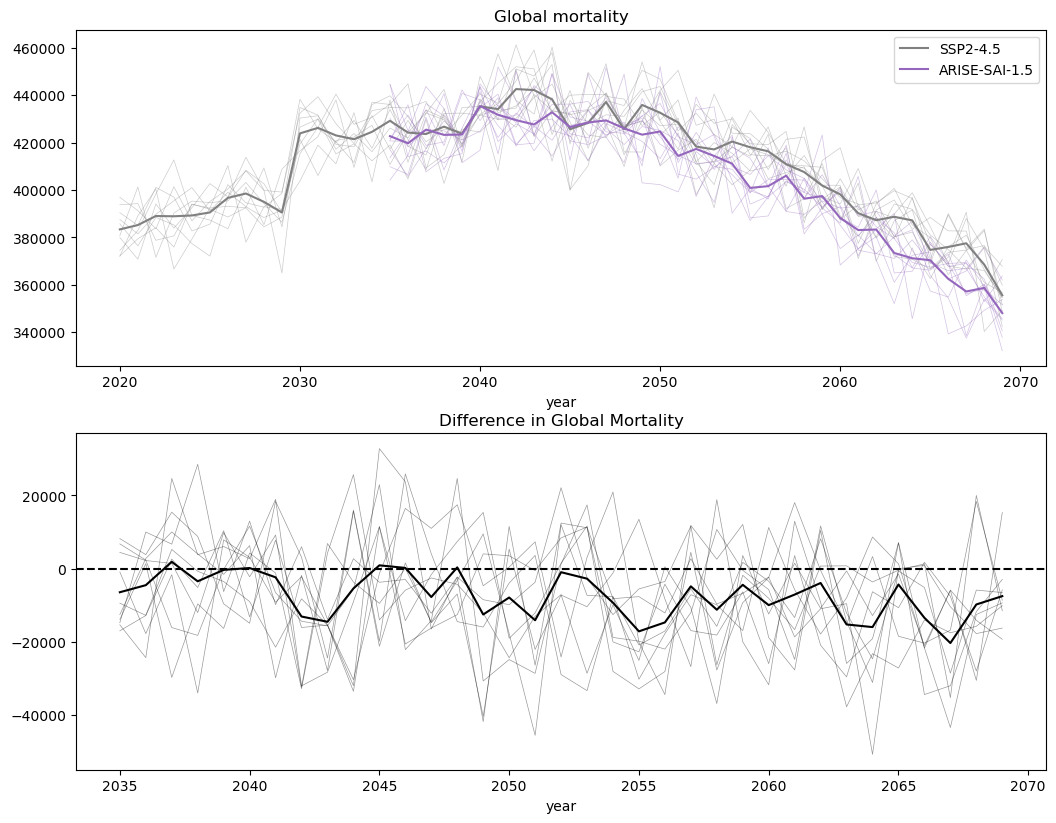

In [38]:
fig = plt.figure(figsize=autosize_figure(2, 1, xscale_factor=1.5))
gs = GridSpec(2, 1) # rows, columns

ax1 = fig.add_subplot(gs[0, 0])
for ens_num in range(1, 11):
    ssp245.sel(ensemble=ens_num, quantile="median").plot(color='grey', alpha=0.4, linewidth=0.5)
    arise.sel(ensemble=ens_num, quantile="median").plot(color='tab:purple', alpha=0.4, linewidth=0.5)
ssp245.mean("ensemble").sel(quantile="median").plot(color='grey', label="SSP2-4.5")
arise.mean("ensemble").sel(quantile="median").plot(color='tab:purple', label="ARISE-SAI-1.5")
plt.title("Global mortality")
plt.legend()

ax2 = fig.add_subplot(gs[1, 0])
ssp245_time = ssp245.sel(year=slice(2035, 2069))
for ens_num in range(1, 11):
    (arise - ssp245_time).sel(ensemble=ens_num, quantile="median").plot(color='k', alpha=0.4, linewidth=0.5)
(arise - ssp245_time).mean("ensemble").sel(quantile="median").plot(color='k')
plt.axhline(0, color='k', linestyle='--')
plt.title("Difference in Global Mortality")